In [ ]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/jan-2025.csv'
buy_codes = [1, 2, 3, 5]
sell_codes = [4, 8, 10, 11]
cols = ['SUB_ACC', 'ISIN', 'TR_TYPE(*)', 'QUANTITY', 'VALUE (in Rs)', 'TR_DATE']
min_trades = 20

a1, a2, a3, a4 = 0.4, 0.4, 0.1, 0.1
nu = 13

In [ ]:
df = pd.read_csv(file_path, usecols=cols)
df['TR_DATE'] = pd.to_datetime(df['TR_DATE'])

In [ ]:
df = df[df['TR_TYPE(*)'].isin(buy_codes + sell_codes)].copy()
df = df.dropna(subset=['SUB_ACC'])
df = df[df['SUB_ACC'].str.strip() != '']

df['SIDE'] = 'SELL'
df.loc[df['TR_TYPE(*)'].isin(buy_codes), 'SIDE'] = 'BUY'

foresight_raw = df.groupby('SUB_ACC').apply(
    lambda x: (x['SIDE'] == 'SELL').sum() / len(x)
).reset_index()
foresight_raw.columns = ['SUB_ACC', 'FORESIGHT']

trade_count = df.groupby('SUB_ACC').size().reset_index(name='TRADE_COUNT')
valid_users = trade_count[trade_count['TRADE_COUNT'] >= min_trades]['SUB_ACC']
df = df[df['SUB_ACC'].isin(valid_users)].copy()

df['WEEK'] = df['TR_DATE'].dt.to_period('W')
weekly_trades = df.groupby(['SUB_ACC', 'WEEK']).size().reset_index(name='WEEKLY_COUNT')

print(df['SUB_ACC'].nunique(), 'valid users after filter')

1139 valid users after filter


/tmp/ipykernel_19547/3641242744.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  foresight_raw = df.groupby('SUB_ACC').apply(


In [ ]:
# build completed positions (same as before)
sell_date = (df[df['SIDE']=='SELL']
             .groupby(['SUB_ACC','ISIN'])['TR_DATE'].max()
             .reset_index()
             .rename(columns={'TR_DATE':'CLOSE_DATE'}))

buy_pos = df[df['SIDE']=='BUY'].groupby(['SUB_ACC','ISIN'])[['VALUE (in Rs)','QUANTITY']].sum()
buy_pos.columns = ['BUY_VAL', 'BUY_QTY']
buy_pos = buy_pos.reset_index()

sell_pos = df[df['SIDE']=='SELL'].groupby(['SUB_ACC','ISIN'])[['VALUE (in Rs)','QUANTITY']].sum()
sell_pos.columns = ['SELL_VAL', 'SELL_QTY']
sell_pos = sell_pos.reset_index()

pos = pd.merge(buy_pos, sell_pos, on=['SUB_ACC','ISIN'])
pos = pos[(pos['BUY_QTY']>0) & (pos['SELL_QTY']>0)].copy()

matched_qty = pos[['BUY_QTY','SELL_QTY']].min(axis=1)
pos['AVG_BUY']  = pos['BUY_VAL'] / pos['BUY_QTY']
pos['AVG_SELL'] = pos['SELL_VAL'] / pos['SELL_QTY']
pos['RETURN']   = (pos['AVG_SELL'] - pos['AVG_BUY']) * matched_qty
pos['ROI']      = pos['RETURN'] / pos['BUY_VAL']

pos = pd.merge(pos, sell_date, on=['SUB_ACC','ISIN'], how='left')

# sort by close date — most recent first (i=0 is most recent, per paper notation)
pos = pos.sort_values(['SUB_ACC','CLOSE_DATE'], ascending=[True, False])
pos['i'] = pos.groupby('SUB_ACC').cumcount()  # 0 = most recent

del df, buy_pos, sell_pos, sell_date, trade_count
gc.collect()

print(len(pos), 'positions across', pos['SUB_ACC'].nunique(), 'users')
pos[['SUB_ACC','ISIN','RETURN','ROI','CLOSE_DATE','i']].head()

14158 positions across 710 users


,SUB_ACC,ISIN,RETURN,ROI,CLOSE_DATE,i
0,S1000238085476,INE00H001014,-1.308170e+06,-0.034542,2025-01-29,0
1,S1000238085476,INE758T01015,3.083985e+06,0.039626,2025-01-29,1
2,S1001458825855,INE010J01012,-1.855408e+07,-0.169596,2025-01-30,0
13,S1001811484187,INE860A01027,-3.252756e+06,-0.096718,2025-01-31,0
4,S1001811484187,INE009A01021,-5.498379e+06,-0.035965,2025-01-28,1


In [ ]:
# decay rate per user: lambda = ln(2) / (0.3 * n_positions)
n_pos = pos.groupby('SUB_ACC')['i'].max().reset_index()
n_pos.columns = ['SUB_ACC', 'N_POS']
n_pos['LAMBDA'] = np.log(2) / (0.3 * n_pos['N_POS'])

pos = pd.merge(pos, n_pos, on='SUB_ACC', how='left')
pos['DECAY_W'] = np.exp(-pos['i'] * pos['LAMBDA'])  # e^(-i*lambda)

# --- performance score: sum of decay-weighted returns ---
perf = pos.groupby('SUB_ACC').apply(
    lambda x: (x['DECAY_W'] * x['RETURN']).sum()
).reset_index()
perf.columns = ['SUB_ACC', 'PERF_SCORE']

# --- strategy score: (weighted avg ROI + weighted median ROI) / 2 ---
def weighted_median(values, weights):
    # sort by value, compute cumulative weight, find where it crosses 0.5
    df_tmp = pd.DataFrame({'v': values, 'w': weights}).sort_values('v')
    cumw = df_tmp['w'].cumsum() / df_tmp['w'].sum()
    return df_tmp['v'].iloc[(cumw >= 0.5).argmax()]

def strategy(x):
    w = x['DECAY_W']
    r = x['ROI']
    avg = (w * r).sum() / w.sum()
    med = weighted_median(r.values, w.values)
    return (avg + med) / 2

strat = pos.groupby('SUB_ACC').apply(strategy).reset_index()
strat.columns = ['SUB_ACC', 'STRAT_SCORE']

# --- activity score: sigmoid of percentile rank of n_positions ---
n_pos['PRANK_ACTIVITY'] = 1 - n_pos['N_POS'].rank(pct=True, ascending=True) + 1/len(n_pos)
n_pos['ACTIVITY_SCORE'] = n_pos['N_POS'] / (1 + np.exp(-nu * (n_pos['PRANK_ACTIVITY'] - 0.5)))

print('perf, strat, activity computed')
perf.head()

/tmp/ipykernel_19547/659801780.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  perf = pos.groupby('SUB_ACC').apply(
/tmp/ipykernel_19547/659801780.py:25: RuntimeWarning: invalid value encountered in scalar divide
  avg = (w * r).sum() / w.sum()


perf, strat, activity computed


/tmp/ipykernel_19547/659801780.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat = pos.groupby('SUB_ACC').apply(strategy).reset_index()


,SUB_ACC,PERF_SCORE
0,S1000238085476,-1.002200e+06
1,S1001458825855,0.000000e+00
2,S1001811484187,-1.149668e+07
3,S1002028504698,-2.532639e+04
4,S1002516800850,1.226259e+06


In [ ]:
# bring everything together
scores = (
    perf
    .merge(strat, on='SUB_ACC')
    .merge(n_pos[['SUB_ACC','N_POS','ACTIVITY_SCORE']], on='SUB_ACC')
    .merge(foresight_raw, on='SUB_ACC', how='left')
)
scores['FORESIGHT'] = scores['FORESIGHT'].fillna(0)

# percentile rank helper: prank = 1 - rank/rankmax
def prank(series):
    return 1 - series.rank(ascending=True) / series.rank(ascending=True).max()

# f(x) = 799x + 200
def f(x):
    return 799 * x + 200

scores['OPTRAS'] = (
    a1 * f(prank(scores['PERF_SCORE'])) +
    a2 * f(prank(scores['STRAT_SCORE'])) +
    a3 * f(prank(scores['ACTIVITY_SCORE'])) +
    a4 * f(prank(scores['FORESIGHT']))
)

print('optras score range:', round(scores['OPTRAS'].min(),1), 'to', round(scores['OPTRAS'].max(),1))
print('mean:', round(scores['OPTRAS'].mean(),1), '  median:', round(scores['OPTRAS'].median(),1))
scores[['SUB_ACC','PERF_SCORE','STRAT_SCORE','ACTIVITY_SCORE','FORESIGHT','OPTRAS']].head(10)

optras score range: 230.2 to 924.4
mean: 601.7   median: 633.0


,SUB_ACC,PERF_SCORE,STRAT_SCORE,ACTIVITY_SCORE,FORESIGHT,OPTRAS
0,S1000238085476,-1.002200e+06,-0.031194,0.929674,0.512195,737.426239
1,S1001458825855,0.000000e+00,NaN,0.000000,0.538462,NaN
2,S1001811484187,-1.149668e+07,-0.083782,0.152249,0.524752,881.590704
3,S1002028504698,-2.532639e+04,-0.001379,0.929674,0.924731,522.662278
4,S1002516800850,1.226259e+06,0.004532,0.361715,0.500000,412.043827
5,S1004876898916,1.299109e+06,0.010559,0.929674,0.454545,386.010957
6,S1006287532243,-1.184224e+07,-0.057040,0.152249,0.706714,837.339817
7,S1006531680319,1.990097e+06,0.424272,0.529606,0.520000,311.077514
8,S1007372634802,1.663695e+06,0.347281,0.929674,0.862069,266.090145
9,S1007454017494,0.000000e+00,NaN,0.000000,0.500000,NaN


In [ ]:
# consistent = had >= 20 trades in at least one week
max_weekly = weekly_trades.groupby('SUB_ACC')['WEEKLY_COUNT'].max().reset_index()
max_weekly['GROUP'] = max_weekly['WEEKLY_COUNT'].apply(
    lambda x: 'Consistent' if x >= 20 else 'Inconsistent'
)

scores = pd.merge(scores, max_weekly[['SUB_ACC','GROUP']], on='SUB_ACC', how='left')
scores['GROUP'] = scores['GROUP'].fillna('Inconsistent')

print(scores['GROUP'].value_counts())
print()
print('consistent mean optras:', round(scores[scores['GROUP']=='Consistent']['OPTRAS'].mean(),1))
print('inconsistent mean optras:', round(scores[scores['GROUP']=='Inconsistent']['OPTRAS'].mean(),1))

GROUP
Consistent      541
Inconsistent    169
Name: count, dtype: int64

consistent mean optras: 610.7
inconsistent mean optras: 561.8


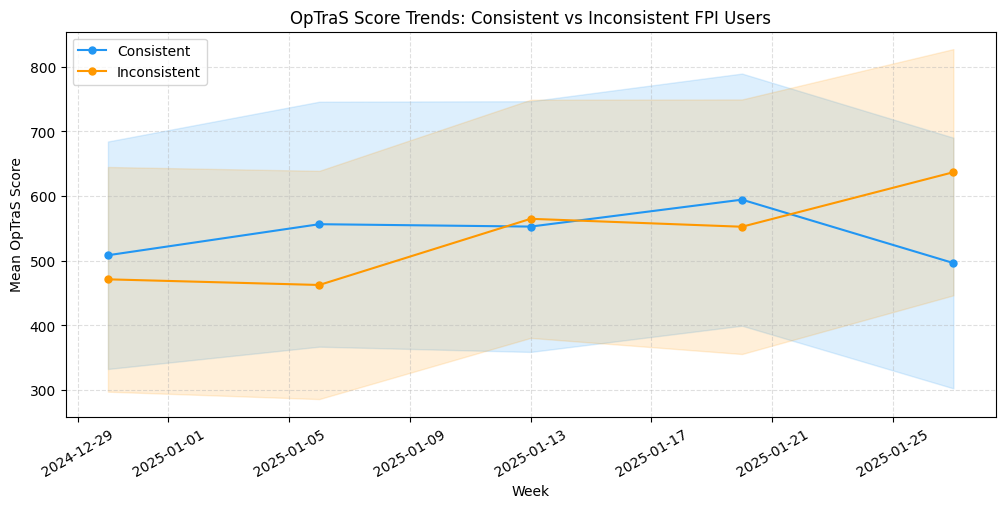

In [ ]:
# weekly optras — compute mean optras per group per week
# merge week info back onto positions
pos_week = pos[['SUB_ACC','CLOSE_DATE']].copy()
pos_week['WEEK'] = pos_week['CLOSE_DATE'].dt.to_period('W').dt.start_time
pos_week = pd.merge(pos_week, scores[['SUB_ACC','OPTRAS','GROUP']], on='SUB_ACC', how='left')

weekly_optras = pos_week.groupby(['GROUP','WEEK'])['OPTRAS'].agg(['mean','std']).reset_index()
weekly_optras.columns = ['GROUP','WEEK','MEAN_OPTRAS','STD_OPTRAS']

fig, ax = plt.subplots(figsize=(12, 5))

colors = {'Consistent': '#2196F3', 'Inconsistent': '#FF9800'}

for grp in ['Consistent', 'Inconsistent']:
    sub = weekly_optras[weekly_optras['GROUP']==grp].sort_values('WEEK')
    ax.plot(sub['WEEK'], sub['MEAN_OPTRAS'], '-o', color=colors[grp], label=grp, markersize=5)
    ax.fill_between(sub['WEEK'],
                    sub['MEAN_OPTRAS'] - sub['STD_OPTRAS'],
                    sub['MEAN_OPTRAS'] + sub['STD_OPTRAS'],
                    alpha=0.15, color=colors[grp])

ax.set_xlabel('Week')
ax.set_ylabel('Mean OpTraS Score')
ax.set_title('OpTraS Score Trends: Consistent vs Inconsistent FPI Users')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30)
plt.show()